# N.B.: 
- In the following trainings, only the MSE loss is used (no comparison with Huber loss)

# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

PROJECT_ROOT = os.path.abspath("..")  # notebooks/
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis
import fm.massInference as massInference

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})

# Fine-Tuning Trainings

## Load the Datasets

In [4]:
with open("df_H_event.pkl", "rb") as f:
    df_H = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY = pickle.load(f)

In [5]:
df_all = (
    pd.concat([df_DY, df_H], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all, seed=0)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


## Context and Target Definition

In [6]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

## Training SetUp 

In [7]:
PROJECT_ROOT = os.path.abspath("..")  # notebooks/

OUT_PREPARED_UNBAL = os.path.join(PROJECT_ROOT, "results", "prepared_splits", "unbalanced")
OUT_PREPARED_BAL   = os.path.join(PROJECT_ROOT, "results", "prepared_splits", "balanced")

os.makedirs(OUT_PREPARED_UNBAL, exist_ok=True)
os.makedirs(OUT_PREPARED_BAL, exist_ok=True)

OUT_PREPARED_UNBAL, OUT_PREPARED_BAL

('/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced',
 '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced')

In [8]:
# Creo gli splits per balanced e unbalanced :
MODES_ALL = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_GLOBAL__Y_LOCAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

# Balanced : 
OUT_PREPARED_BAL = os.path.join(PROJECT_ROOT, "results", "prepared_splits", "balanced")
os.makedirs(OUT_PREPARED_BAL, exist_ok=True)

mode_dirs_bal = data.apply_and_save_selected_scalings(
    df=df_bal,                 # <-- balanced fisico
    out_root=OUT_PREPARED_BAL,
    train_cols=train_cols,
    y_cols=y_cols,
    modes=MODES_ALL,
    split_kind="physics",
    class_col="class",
)

mode_dirs_bal

{'X_NONE__Y_NONE': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced/X_NONE__Y_NONE',
 'X_GLOBAL__Y_GLOBAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced/X_GLOBAL__Y_GLOBAL',
 'X_GLOBAL__Y_LOCAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced/X_GLOBAL__Y_LOCAL',
 'X_LOCAL__Y_LOCAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced/X_LOCAL__Y_LOCAL',
 'X_NONE__Y_LOCAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced/X_NONE__Y_LOCAL'}

In [9]:
# Unbalanced :
OUT_PREPARED_UNBAL = os.path.join(PROJECT_ROOT, "results", "prepared_splits", "unbalanced")
os.makedirs(OUT_PREPARED_UNBAL, exist_ok=True)

mode_dirs_unbal = data.apply_and_save_selected_scalings(
    df=df_all,                 # <-- unbalanced fisico
    out_root=OUT_PREPARED_UNBAL,
    train_cols=train_cols,
    y_cols=y_cols,
    modes=MODES_ALL,
    split_kind="physics",
    class_col="class",
)

mode_dirs_unbal

{'X_NONE__Y_NONE': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced/X_NONE__Y_NONE',
 'X_GLOBAL__Y_GLOBAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced/X_GLOBAL__Y_GLOBAL',
 'X_GLOBAL__Y_LOCAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced/X_GLOBAL__Y_LOCAL',
 'X_LOCAL__Y_LOCAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL',
 'X_NONE__Y_LOCAL': '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced/X_NONE__Y_LOCAL'}

In [10]:
# Load the pre-trainings:
PRETRAIN_FLAT_NO   = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "flat", "X_NONE__Y_NONE")
PRETRAIN_FLAT_GLOB = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "flat", "X_GLOBAL__Y_GLOBAL")

pre_no   = training.load_run(PRETRAIN_FLAT_NO, device="cpu")
pre_glob = training.load_run(PRETRAIN_FLAT_GLOB, device="cpu")

init_state_no   = pre_no["model"].state_dict()
init_state_glob = pre_glob["model"].state_dict()

print("Loaded init A (flat NO-SCALE):", PRETRAIN_FLAT_NO)
print("Loaded init B (flat GLOBAL):  ", PRETRAIN_FLAT_GLOB)

Loaded init A (flat NO-SCALE): /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/flat/X_NONE__Y_NONE
Loaded init B (flat GLOBAL):   /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/flat/X_GLOBAL__Y_GLOBAL


In [11]:
# Definisco anche delle cartelle di output :
OUT_FT_A = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "balanced", "FT_from_flat_noscale")
OUT_FT_B = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "balanced", "FT_from_flat_global")

os.makedirs(OUT_FT_A, exist_ok=True)
os.makedirs(OUT_FT_B, exist_ok=True)

print("OUT_FT_A:", OUT_FT_A)
print("OUT_FT_B:", OUT_FT_B)

OUT_FT_A: /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/balanced/FT_from_flat_noscale
OUT_FT_B: /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/balanced/FT_from_flat_global


### Training Balanced

In [12]:
results_ft_A = {}  # init da flat NO-SCALE
results_ft_B = {}  # init da flat GLOBAL

for mode in MODES_ALL:

    mode_dir = mode_dirs_bal[mode]          # prepared splits directory
    save_dir_A = os.path.join(OUT_FT_A, mode)
    save_dir_B = os.path.join(OUT_FT_B, mode)

    print("\n" + "=" * 90)
    print(f"FINETUNE A (init=flat NO-SCALE) | mode={mode}")
    print("prepared:", mode_dir)
    print("save:    ", save_dir_A)
    print("=" * 90)

    resA = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        device=DEVICE,
        init_state_dict=init_state_no,
        strict_init=True,
        # loss_type="mse",     <-- just so i know 
    )
    training.save_run(resA, save_dir_A)
    results_ft_A[mode] = resA

    print("\n" + "=" * 90)
    print(f"FINETUNE B (init=flat GLOBAL)  | mode={mode}")
    print("prepared:", mode_dir)
    print("save:    ", save_dir_B)
    print("=" * 90)

    resB = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        device=DEVICE,
        init_state_dict=init_state_glob,
        strict_init=True,
        # loss_type="mse",     <-- just so i know
    )
    training.save_run(resB, save_dir_B)
    results_ft_B[mode] = resB

print("\nDone. Saved fine-tuned runs in:")
print("A:", OUT_FT_A)
print("B:", OUT_FT_B)


FINETUNE A (init=flat NO-SCALE) | mode=X_NONE__Y_NONE
prepared: /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/balanced/X_NONE__Y_NONE
save:     /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/balanced/FT_from_flat_noscale/X_NONE__Y_NONE
[ep    1] train=4.428793  val=1.408527  best=1.408527  bad=0/30
[ep   10] train=1.049462  val=1.321003  best=0.947496  bad=8/30
[ep   20] train=0.972055  val=1.002020  best=0.947496  bad=18/30
[ep   30] train=1.005036  val=0.871278  best=0.811046  bad=5/30
[ep   40] train=1.035523  val=0.867924  best=0.799222  bad=3/30
[ep   50] train=0.997217  val=1.177930  best=0.627325  bad=5/30
[ep   60] train=0.700862  val=1.938460  best=0.627325  bad=15/30
[ep   70] train=0.617260  val=0.599137  best=0.598801  bad=1/30
[ep   80] train=0.717402  val=0.660514  best=0.564410  bad=2/30
[ep   90] train=0.826383  val=0.733108  best=0.564410  bad=12/30
[ep  100] train=0.747260  v

### Training Unbalanced

In [13]:
OUT_FT_A_UNBAL = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "unbalanced", "FT_from_flat_noscale")
OUT_FT_B_UNBAL = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "unbalanced", "FT_from_flat_global")

os.makedirs(OUT_FT_A_UNBAL, exist_ok=True)
os.makedirs(OUT_FT_B_UNBAL, exist_ok=True)

results_ft_A_unbal = {}
results_ft_B_unbal = {}

for mode in MODES_ALL:

    mode_dir = mode_dirs_unbal[mode]
    save_dir_A = os.path.join(OUT_FT_A_UNBAL, mode)
    save_dir_B = os.path.join(OUT_FT_B_UNBAL, mode)

    print("\n" + "=" * 90)
    print(f"UNBAL FINETUNE A (init=flat NO-SCALE) | mode={mode}")
    print("prepared:", mode_dir)
    print("save:    ", save_dir_A)
    print("=" * 90)

    resA = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        device=DEVICE,                 
        init_state_dict=init_state_no,
        strict_init=True,
    )
    training.save_run(resA, save_dir_A)
    results_ft_A_unbal[mode] = resA

    print("\n" + "=" * 90)
    print(f"UNBAL FINETUNE B (init=flat GLOBAL)  | mode={mode}")
    print("prepared:", mode_dir)
    print("save:    ", save_dir_B)
    print("=" * 90)

    resB = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        device=DEVICE,
        init_state_dict=init_state_glob,
        strict_init=True,
    )
    training.save_run(resB, save_dir_B)
    results_ft_B_unbal[mode] = resB

print("\nDone. Saved fine-tuned UNBAL runs in:")
print("A:", OUT_FT_A_UNBAL)
print("B:", OUT_FT_B_UNBAL)


UNBAL FINETUNE A (init=flat NO-SCALE) | mode=X_NONE__Y_NONE
prepared: /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/unbalanced/X_NONE__Y_NONE
save:     /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/unbalanced/FT_from_flat_noscale/X_NONE__Y_NONE
[ep    1] train=2.785577  val=1.092260  best=1.092260  bad=0/30
[ep   10] train=1.083991  val=0.981515  best=0.980231  bad=2/30
[ep   20] train=0.925212  val=0.769611  best=0.769611  bad=0/30
[ep   30] train=0.702190  val=0.690966  best=0.667310  bad=5/30
[ep   40] train=0.635773  val=0.626890  best=0.617937  bad=1/30
[ep   50] train=0.604390  val=0.584596  best=0.580734  bad=2/30
[ep   60] train=0.576728  val=0.546430  best=0.546430  bad=0/30
[ep   70] train=0.589783  val=0.585519  best=0.546430  bad=10/30
[ep   80] train=0.548981  val=0.526094  best=0.526094  bad=0/30
[ep   90] train=0.556204  val=0.527692  best=0.526094  bad=10/30
[ep  100] train=0.

## Loss Plots

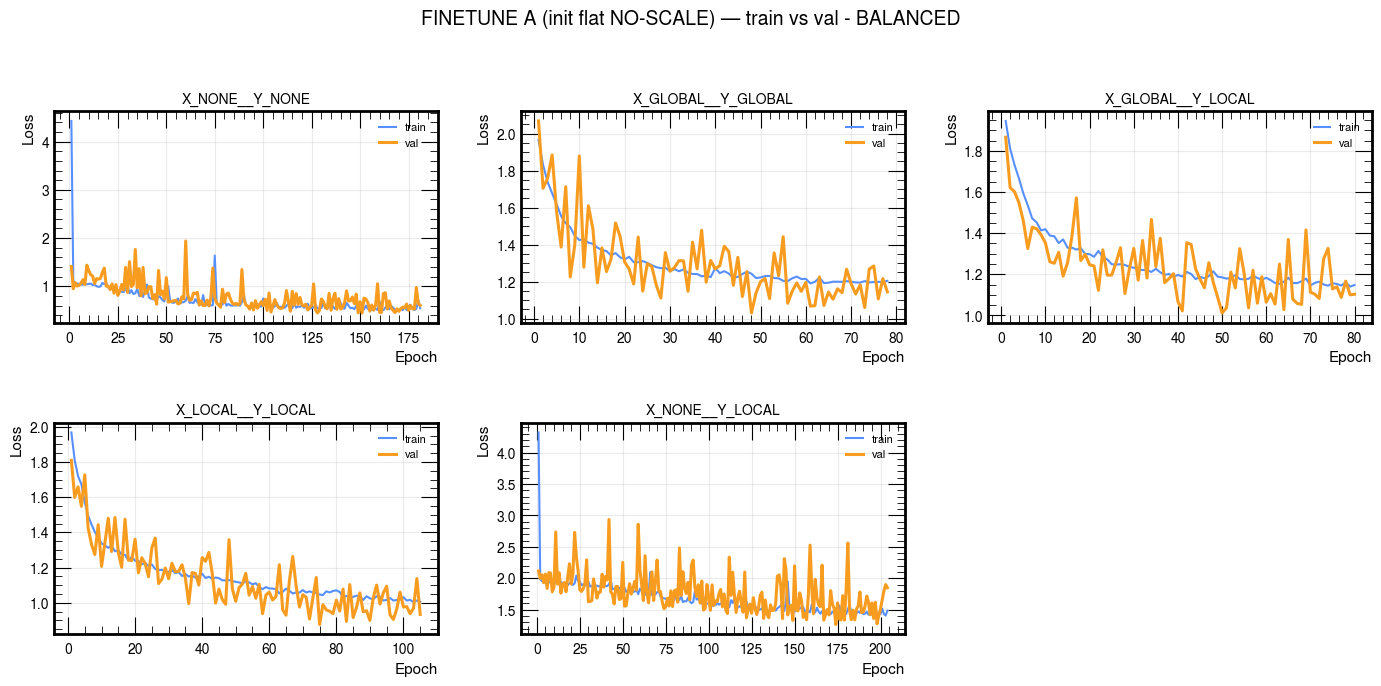

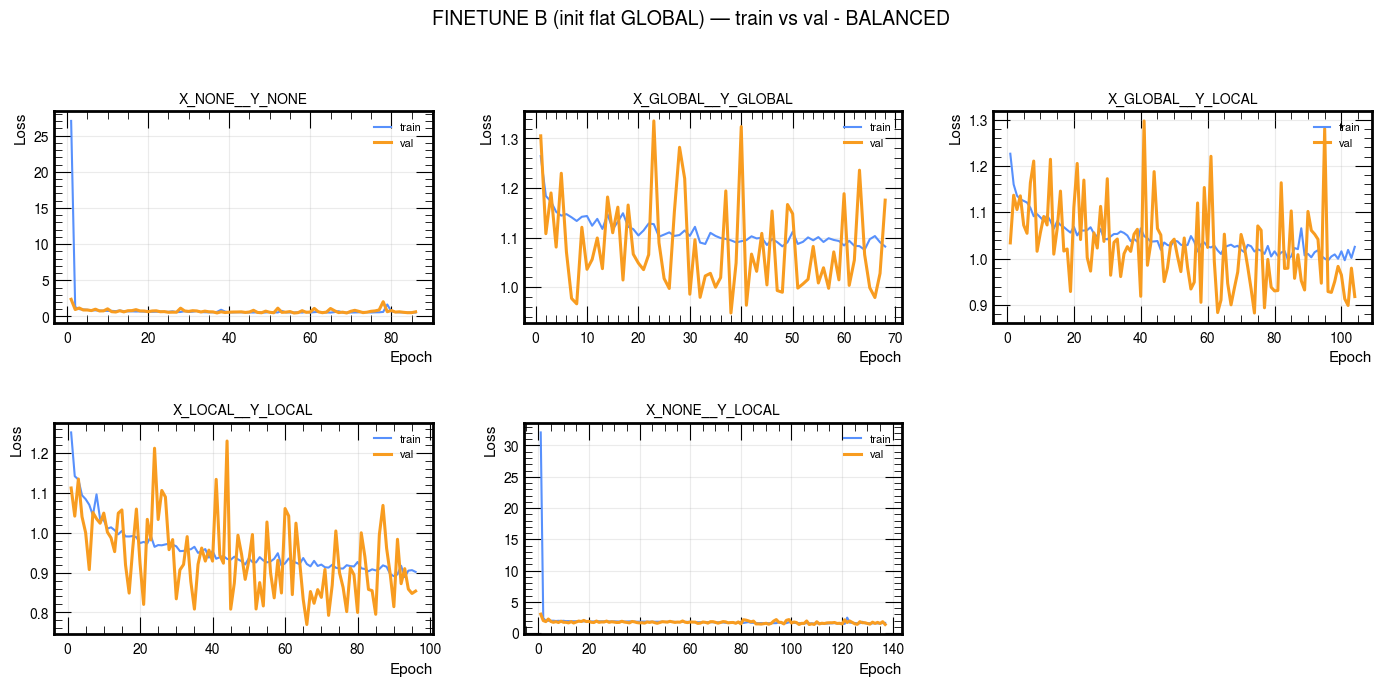

In [14]:
lossPlots.plot_loss_grid(results_ft_A, title="FINETUNE A (init flat NO-SCALE) — train vs val - BALANCED", order=MODES_ALL, logy=False)
lossPlots.plot_loss_grid(results_ft_B, title="FINETUNE B (init flat GLOBAL) — train vs val - BALANCED", order=MODES_ALL, logy=False)

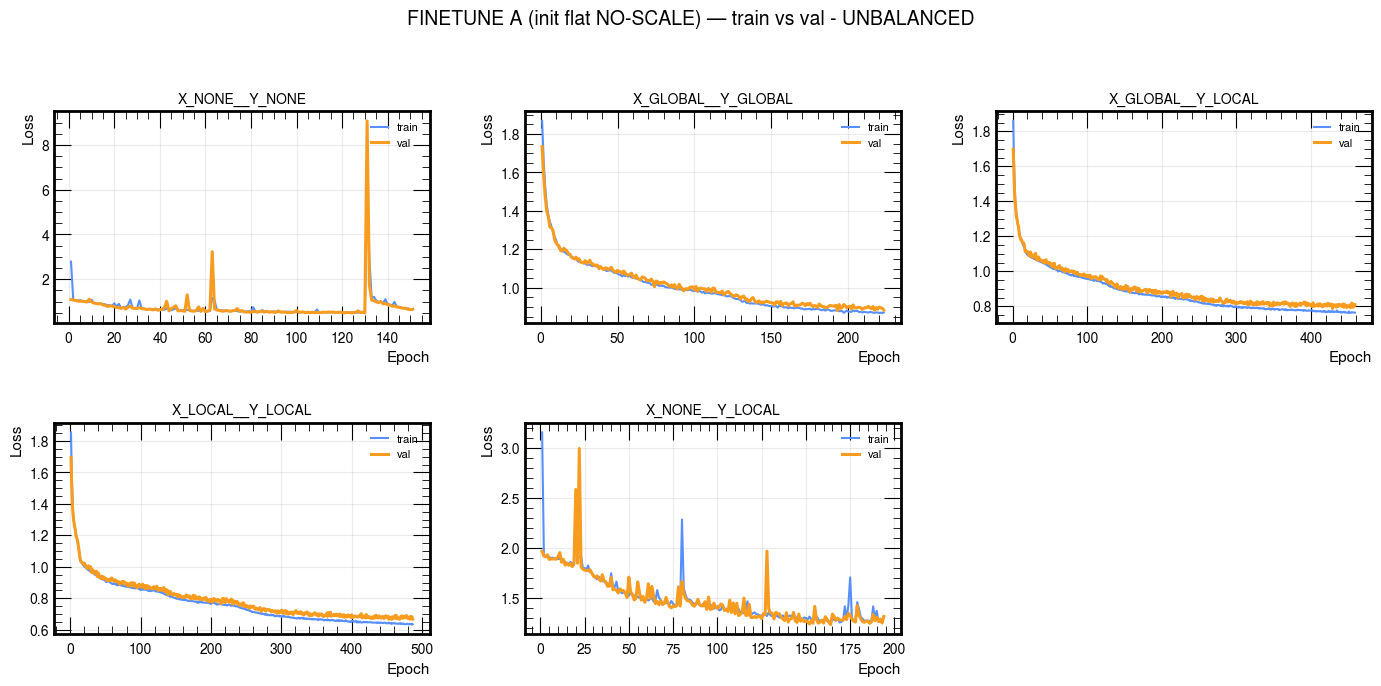

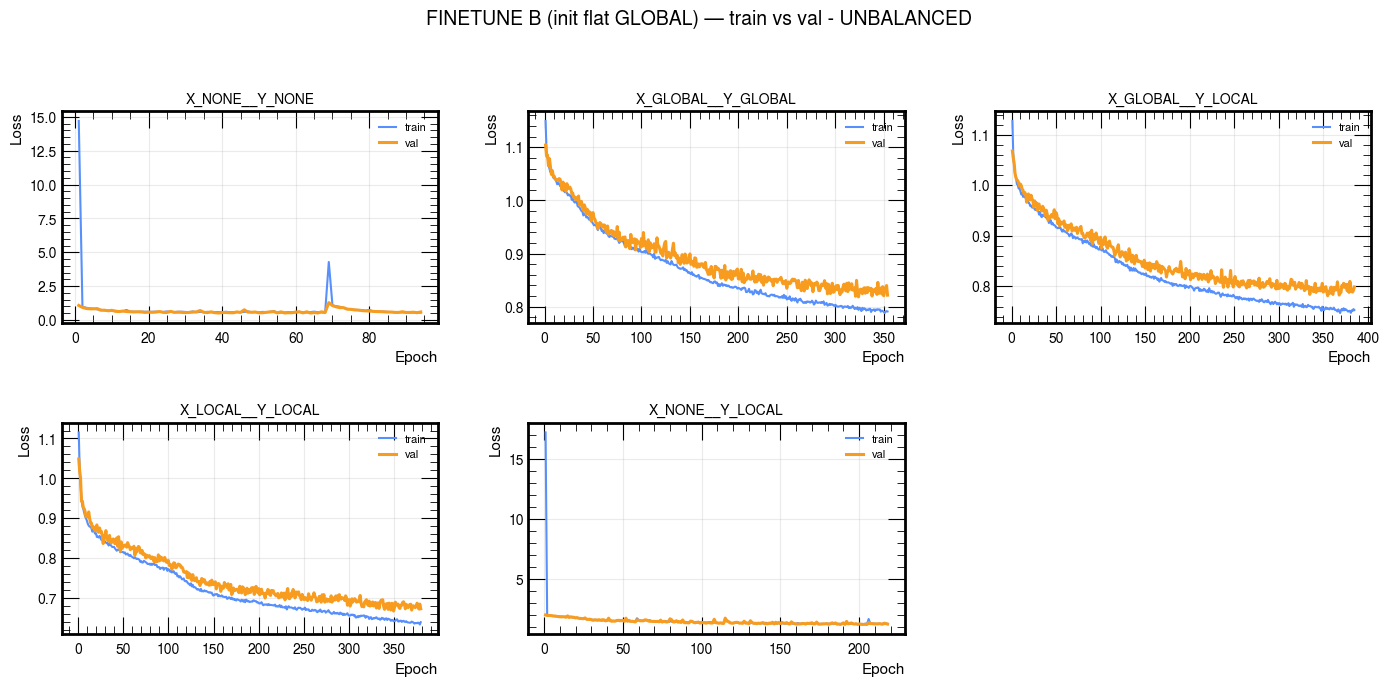

In [15]:
lossPlots.plot_loss_grid(
    results_ft_A_unbal,
    title="FINETUNE A (init flat NO-SCALE) — train vs val - UNBALANCED",
    order=MODES_ALL,
    logy=False,
)

lossPlots.plot_loss_grid(
    results_ft_B_unbal,
    title="FINETUNE B (init flat GLOBAL) — train vs val - UNBALANCED",
    order=MODES_ALL,
    logy=False,
)

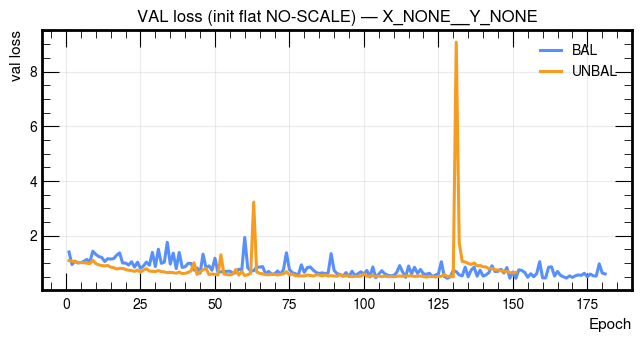

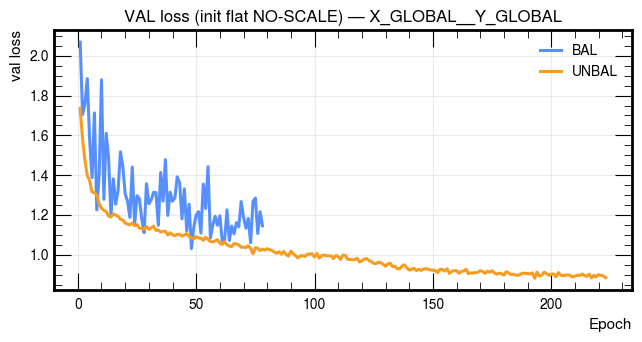

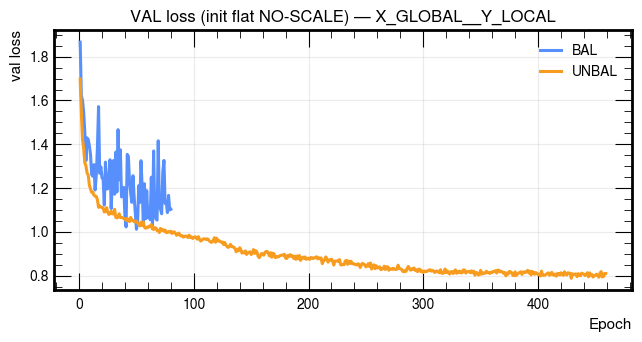

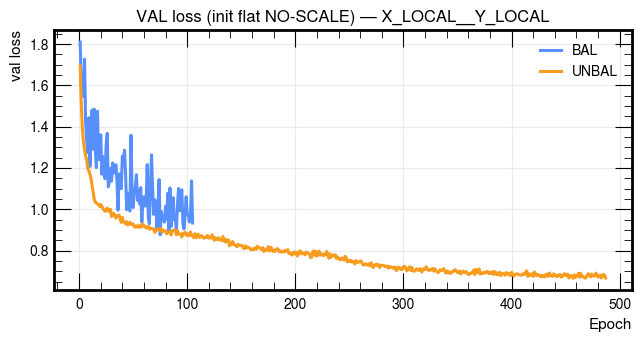

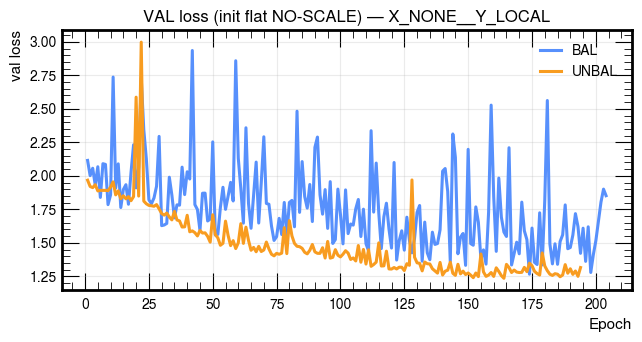

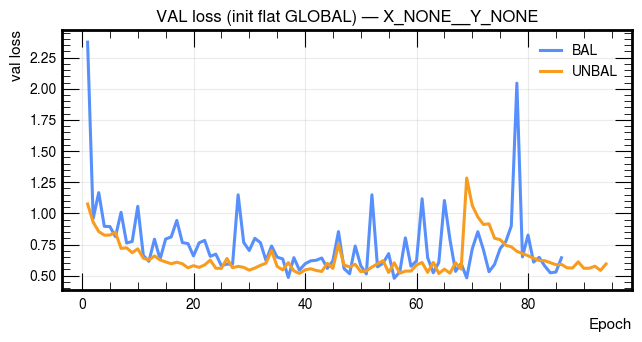

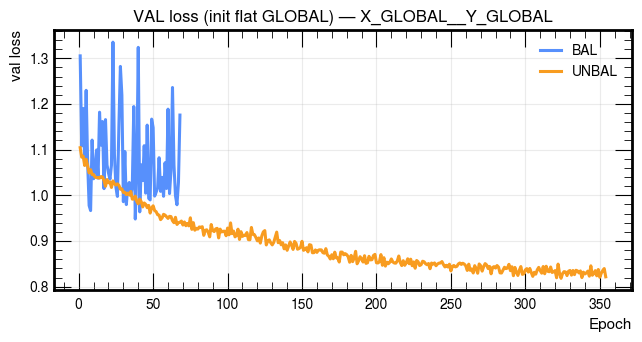

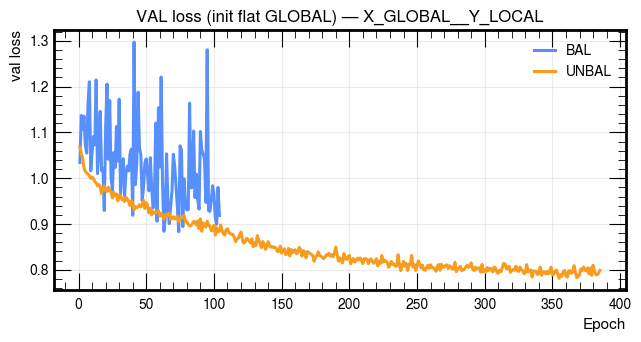

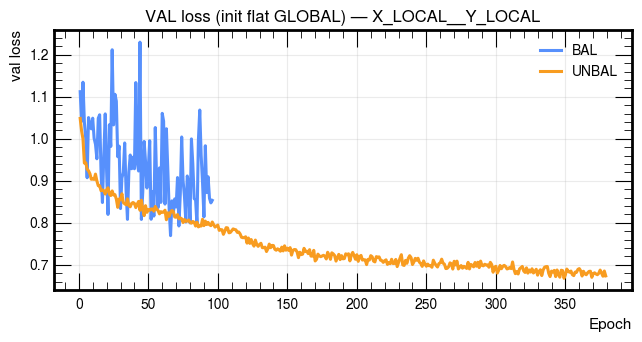

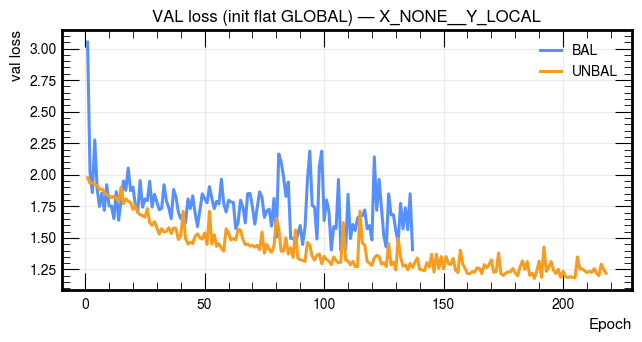

In [16]:
lossPlots.plot_val_bal_vs_unbal_per_mode(
    results_ft_A,
    results_ft_A_unbal,
    title_prefix="VAL loss (init flat NO-SCALE)",
    modes=MODES_ALL,
    logy=False,
)

lossPlots.plot_val_bal_vs_unbal_per_mode(
    results_ft_B,
    results_ft_B_unbal,
    title_prefix="VAL loss (init flat GLOBAL)",
    modes=MODES_ALL,
    logy=False,
)

# Mass Plots

In [17]:
# paths corretti
OUT_FT_A_BAL = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "balanced", "FT_from_flat_noscale")
OUT_FT_B_BAL = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "balanced", "FT_from_flat_global")

OUT_FT_A_UNB = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "unbalanced", "FT_from_flat_noscale")
OUT_FT_B_UNB = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "unbalanced", "FT_from_flat_global")

In [18]:
# Balanced 
masses_A_bal, rawtests_bal = massInference.build_fm_masses_from_runs(
    run_root=OUT_FT_A_BAL,
    prepared_root=OUT_PREPARED_BAL,
    modes=MODES_ALL,
    train_cols=train_cols,
    y_cols=y_cols,
)

masses_B_bal, _ = massInference.build_fm_masses_from_runs(
    run_root=OUT_FT_B_BAL,
    prepared_root=OUT_PREPARED_BAL,
    modes=MODES_ALL,
    train_cols=train_cols,
    y_cols=y_cols,
)

# Unbalanced
masses_A_unb, rawtests_unb = massInference.build_fm_masses_from_runs(
    run_root=OUT_FT_A_UNB,
    prepared_root=OUT_PREPARED_UNBAL,
    modes=MODES_ALL,
    train_cols=train_cols,
    y_cols=y_cols,
)

masses_B_unb, _ = massInference.build_fm_masses_from_runs(
    run_root=OUT_FT_B_UNB,
    prepared_root=OUT_PREPARED_UNBAL,
    modes=MODES_ALL,
    train_cols=train_cols,
    y_cols=y_cols,
)

[OK] FT_from_flat_noscale | X_NONE__Y_NONE | N=16390
[OK] FT_from_flat_noscale | X_GLOBAL__Y_GLOBAL | N=16390
[OK] FT_from_flat_noscale | X_GLOBAL__Y_LOCAL | N=16390
[OK] FT_from_flat_noscale | X_LOCAL__Y_LOCAL | N=16390
[OK] FT_from_flat_noscale | X_NONE__Y_LOCAL | N=16390
[OK] FT_from_flat_global | X_NONE__Y_NONE | N=16390
[OK] FT_from_flat_global | X_GLOBAL__Y_GLOBAL | N=16390
[OK] FT_from_flat_global | X_GLOBAL__Y_LOCAL | N=16390
[OK] FT_from_flat_global | X_LOCAL__Y_LOCAL | N=16390
[OK] FT_from_flat_global | X_NONE__Y_LOCAL | N=16390
[OK] FT_from_flat_noscale | X_NONE__Y_NONE | N=33736
[OK] FT_from_flat_noscale | X_GLOBAL__Y_GLOBAL | N=33736
[OK] FT_from_flat_noscale | X_GLOBAL__Y_LOCAL | N=33736
[OK] FT_from_flat_noscale | X_LOCAL__Y_LOCAL | N=33736
[OK] FT_from_flat_noscale | X_NONE__Y_LOCAL | N=33736
[OK] FT_from_flat_global | X_NONE__Y_NONE | N=33736
[OK] FT_from_flat_global | X_GLOBAL__Y_GLOBAL | N=33736
[OK] FT_from_flat_global | X_GLOBAL__Y_LOCAL | N=33736
[OK] FT_from_flat

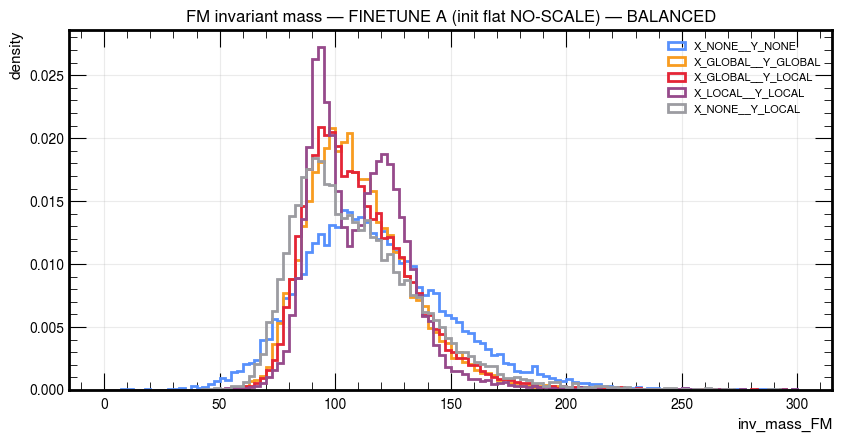

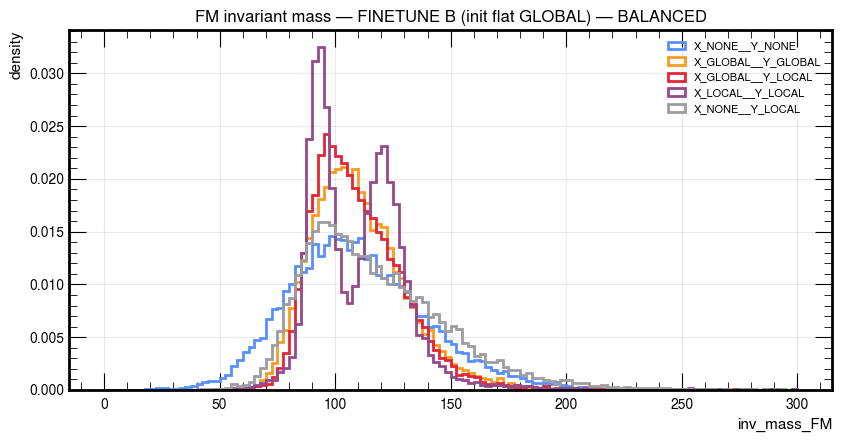

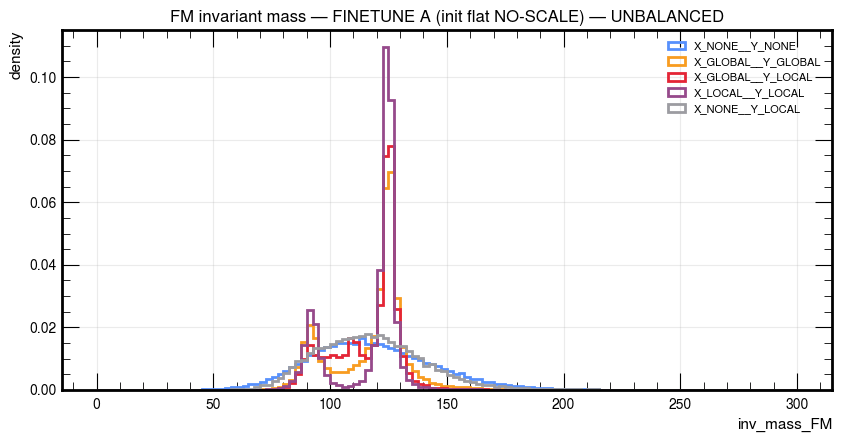

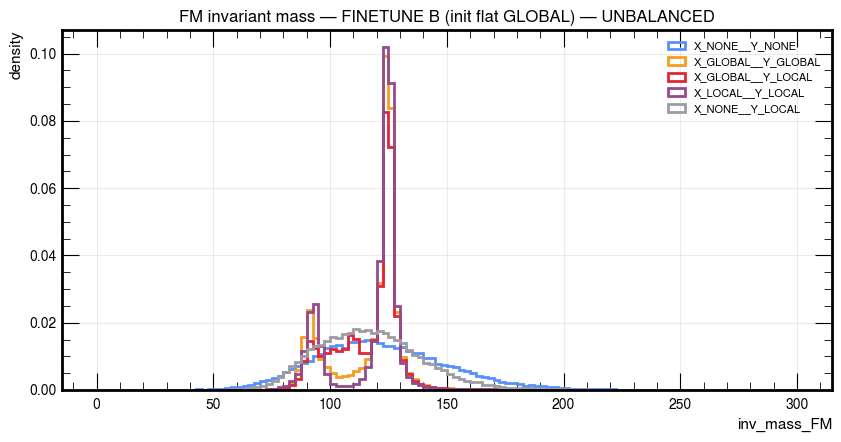

In [19]:
# -------- BALANCED --------
massesPlots.plot_mass_overlay(
    masses_A_bal,
    title="FM invariant mass — FINETUNE A (init flat NO-SCALE) — BALANCED",
    bins=120,
    range_=(0, 300),
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_B_bal,
    title="FM invariant mass — FINETUNE B (init flat GLOBAL) — BALANCED",
    bins=120,
    range_=(0, 300),
    density=True,
)

# -------- UNBALANCED --------
massesPlots.plot_mass_overlay(
    masses_A_unb,
    title="FM invariant mass — FINETUNE A (init flat NO-SCALE) — UNBALANCED",
    bins=120,
    range_=(0, 300),
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_B_unb,
    title="FM invariant mass — FINETUNE B (init flat GLOBAL) — UNBALANCED",
    bins=120,
    range_=(0, 300),
    density=True,
)

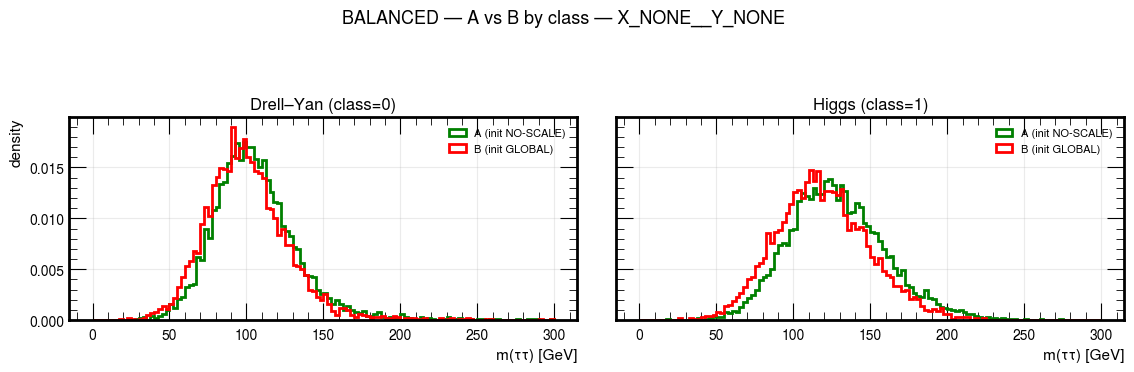

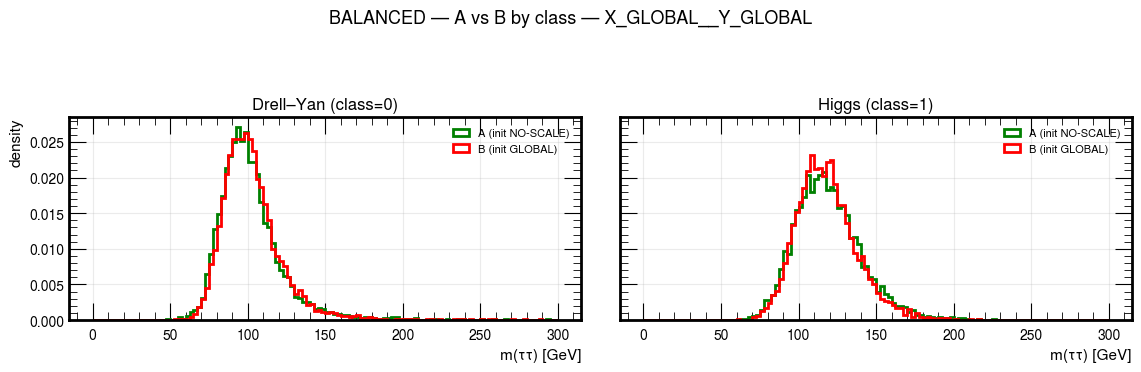

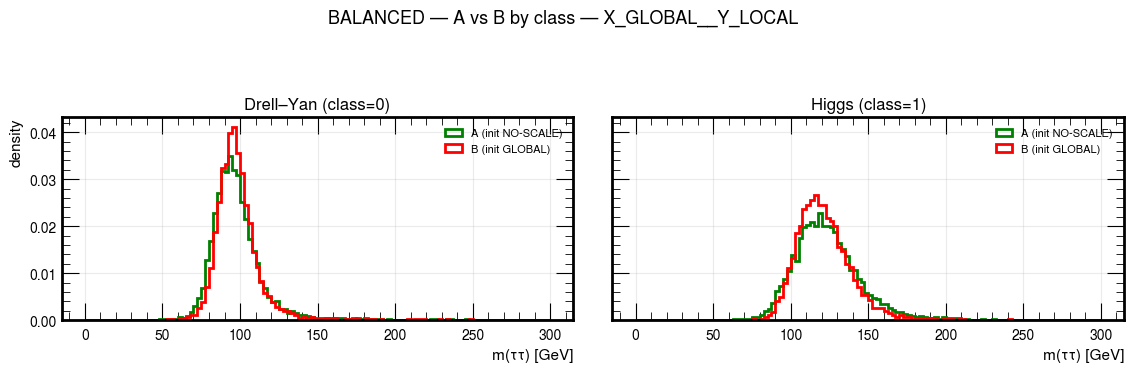

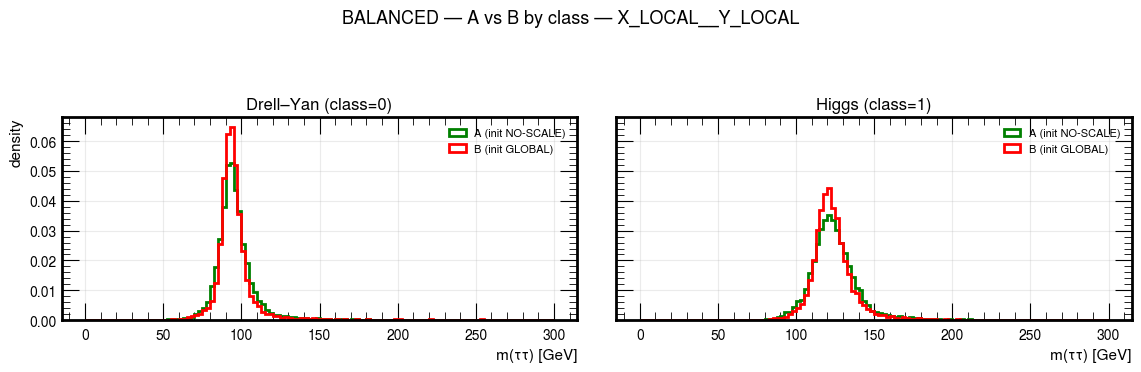

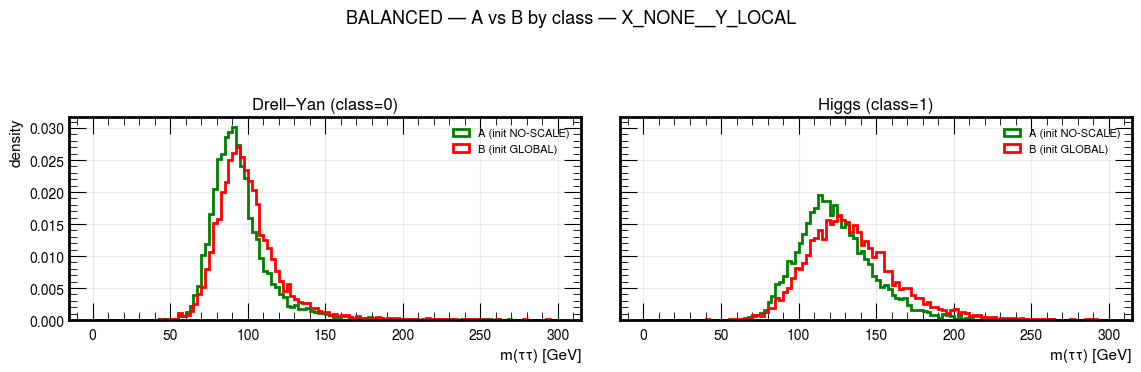

In [74]:
df_test_bal = rawtests_bal[MODES_ALL[0]]

massesPlots.plot_mass_A_vs_B_by_class(
    masses_A=masses_A_bal,
    masses_B=masses_B_bal,
    df_test_raw=df_test_bal,
    modes=MODES_ALL,
    title_prefix="BALANCED — A vs B by class",
    bins=120,
    range_=(0, 300),
    density=True,
)

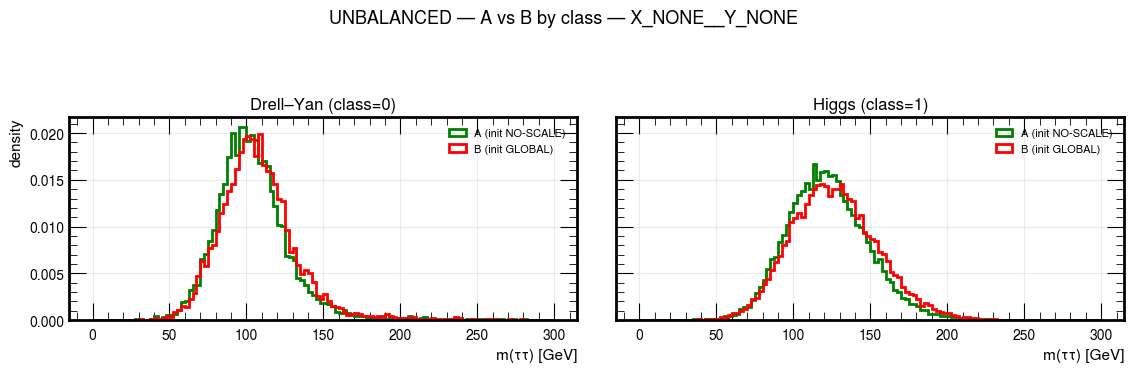

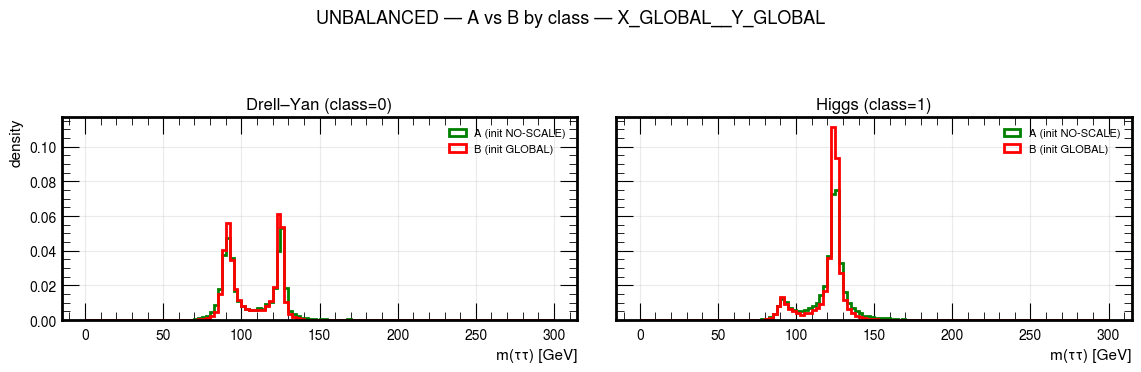

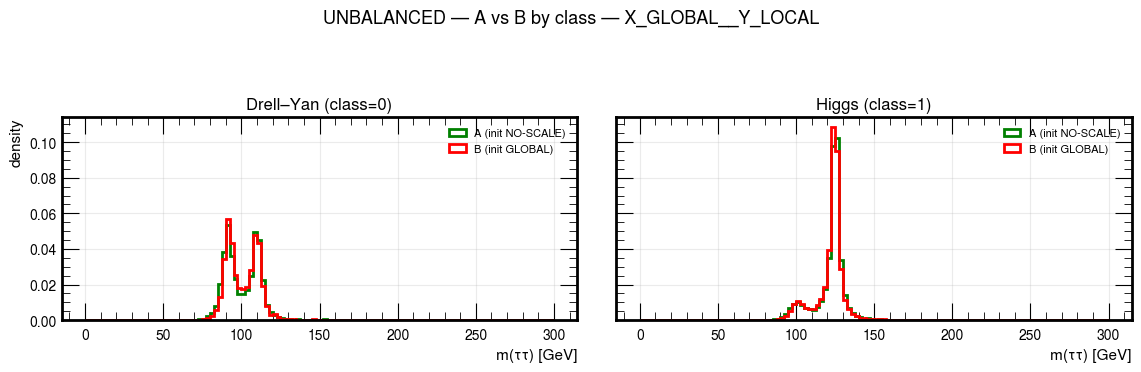

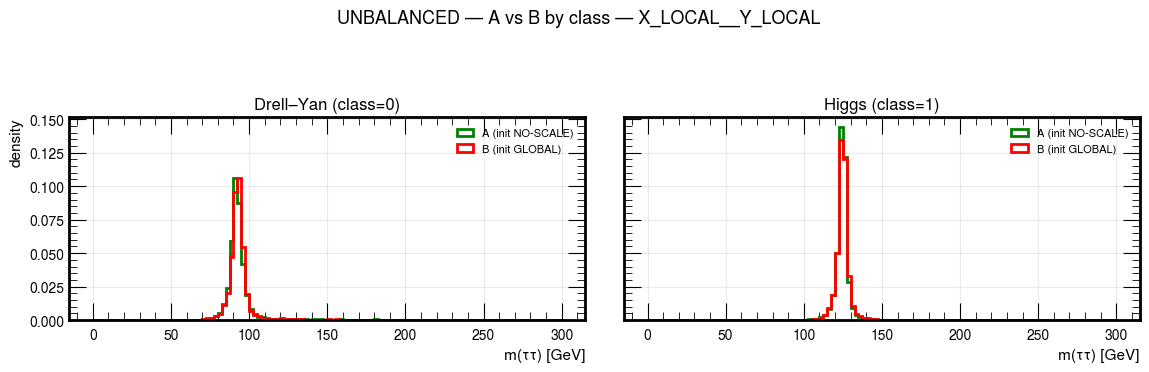

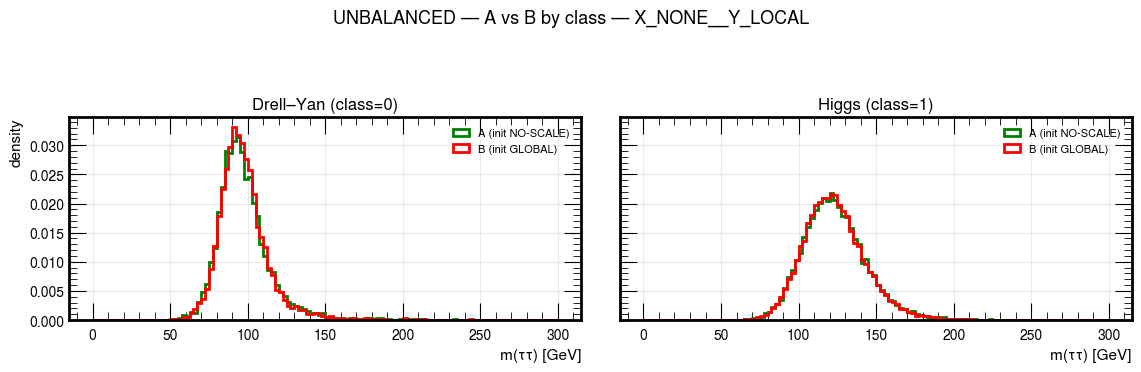

In [75]:
df_test_unbal = rawtests_unb[MODES_ALL[0]]

massesPlots.plot_mass_A_vs_B_by_class(
    masses_A=masses_A_unb,
    masses_B=masses_B_unb,
    df_test_raw=df_test_unbal,
    modes=MODES_ALL,
    title_prefix="UNBALANCED — A vs B by class",
    bins=120,
    range_=(0, 300),
    density=True,
)

## Comparison NO-SCALE vs GLOBAL

In [25]:
rows = []

df_test_bal = rawtests_bal[MODES_ALL[0]]

for mode in MODES_ALL:

    # ---- A
    tmp_A = df_test_bal[["class"]].copy()
    tmp_A["mass"] = np.asarray(masses_A_bal[mode])

    res_A = analysis.compute_S_over_B(
        tmp_A,
        mass_col="mass",
        window=(110, 140),
        class_col="class",
        dy_label=0,
        h_label=1,
    )

    # ---- B
    tmp_B = df_test_bal[["class"]].copy()
    tmp_B["mass"] = np.asarray(masses_B_bal[mode])

    res_B = analysis.compute_S_over_B(
        tmp_B,
        mass_col="mass",
        window=(110, 140),
        class_col="class",
        dy_label=0,
        h_label=1,
    )

    rows.append({
        "mode": mode,
        "A_N_S": res_A["N_S"],
        "A_N_B": res_A["N_B"],
        "A_S_over_B": res_A["S_over_B"],
        "A_S_over_sqrtB": res_A["S_over_sqrtB"],

        "B_N_S": res_B["N_S"],
        "B_N_B": res_B["N_B"],
        "B_S_over_B": res_B["S_over_B"],
        "B_S_over_sqrtB": res_B["S_over_sqrtB"],
    })

df_SB_AB_bal = pd.DataFrame(rows)
df_SB_AB_bal

,mode,A_N_S,A_N_B,A_S_over_B,A_S_over_sqrtB,B_N_S,B_N_B,B_S_over_B,B_S_over_sqrtB
0,X_NONE__Y_NONE,3096,2335,1.325910,64.070411,3048,1983,1.537065,68.446872
1,X_GLOBAL__Y_GLOBAL,4075,1635,2.492355,100.778696,4182,1807,2.314333,98.379577
2,X_GLOBAL__Y_LOCAL,4533,1029,4.405248,141.311671,5018,934,5.372591,164.193976
3,X_LOCAL__Y_LOCAL,6217,543,11.449355,266.797007,6751,365,18.495890,353.363490
4,X_NONE__Y_LOCAL,3957,913,4.334064,130.957586,3631,1466,2.476808,94.832951


$\rightarrow$ La miglior configurazione sembra essere (S/B) B (global flat-training scaling) + Xl + yl

## Comparison with non-flat training

In [62]:
# Loading the non-flat training masses

# balanced
bal_dy_npz = np.load("../results/masses/masses_bal_nonflat_mse_dy.npz")
masses_bal_nonflat_dy = {mode: bal_dy_npz[mode] for mode in bal_dy_npz.files}

bal_h_npz = np.load("../results/masses/masses_bal_nonflat_mse_h.npz")
masses_bal_nonflat_h = {mode: bal_h_npz[mode] for mode in bal_h_npz.files}

# unbalanced
unb_dy_npz = np.load("../results/masses/masses_unbal_nonflat_mse_dy.npz")
masses_unbal_nonflat_dy = {mode: unb_dy_npz[mode] for mode in unb_dy_npz.files}

unb_h_npz = np.load("../results/masses/masses_unbal_nonflat_mse_h.npz")
masses_unbal_nonflat_h = {mode: unb_h_npz[mode] for mode in unb_h_npz.files}

In [63]:
# Separo anche le masse flat per classe:
m_dy_bal = rawtests_bal[MODES_ALL[0]]["class"].to_numpy() == 0
m_h_bal  = rawtests_bal[MODES_ALL[0]]["class"].to_numpy() == 1

masses_bal_flatft_dy = {
    mode: np.asarray(masses_B_bal[mode])[m_dy_bal]
    for mode in SCALING_MODES
}

masses_bal_flatft_h = {
    mode: np.asarray(masses_B_bal[mode])[m_h_bal]
    for mode in SCALING_MODES
}

m_dy_unb = rawtests_unb[MODES_ALL[0]]["class"].to_numpy() == 0
m_h_unb  = rawtests_unb[MODES_ALL[0]]["class"].to_numpy() == 1

masses_unbal_flatft_dy = {
    mode: np.asarray(masses_B_unb[mode])[m_dy_unb]
    for mode in SCALING_MODES
}

masses_unbal_flatft_h = {
    mode: np.asarray(masses_B_unb[mode])[m_h_unb]
    for mode in SCALING_MODES
}

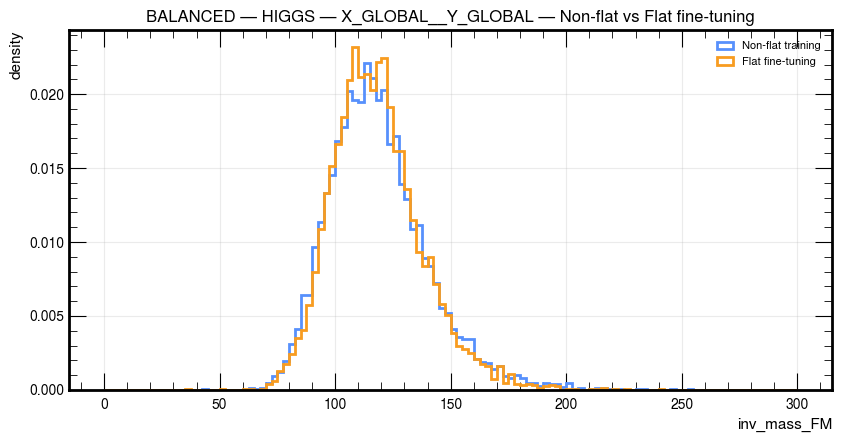

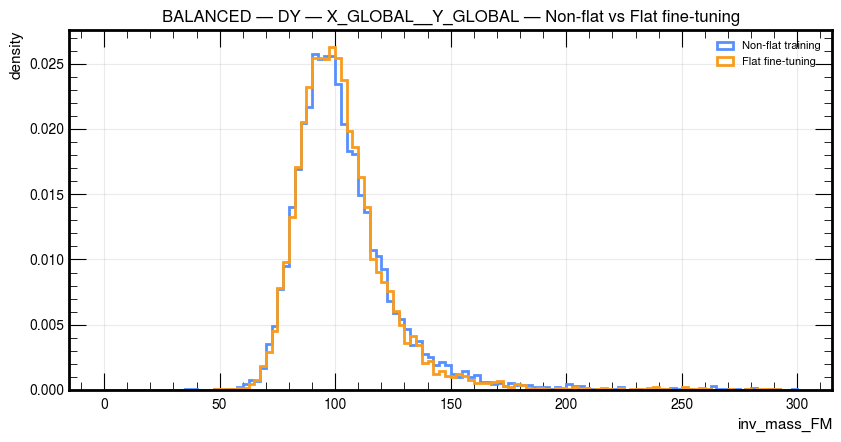

In [83]:
mode = "X_GLOBAL__Y_GLOBAL"

massesPlots.plot_mass_overlay(
    {
        "Non-flat training": masses_bal_nonflat_h[mode],
        "Flat fine-tuning": masses_bal_flatft_h[mode],
    },
    title=f"BALANCED — HIGGS — {mode} — Non-flat vs Flat fine-tuning",
    bins=120,
    range_=common_range,
    density=True,
)
massesPlots.plot_mass_overlay(
    {
        "Non-flat training": masses_bal_nonflat_dy[mode],
        "Flat fine-tuning": masses_bal_flatft_dy[mode],
    },
    title=f"BALANCED — DY — {mode} — Non-flat vs Flat fine-tuning",
    bins=120,
    range_=common_range,
    density=True,
)

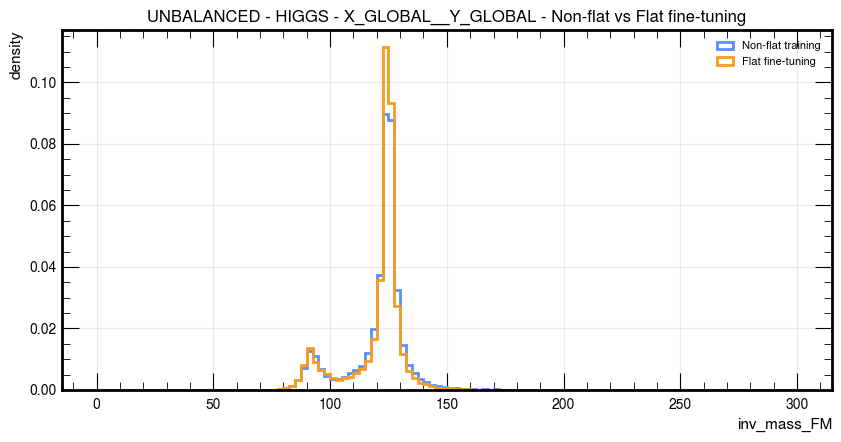

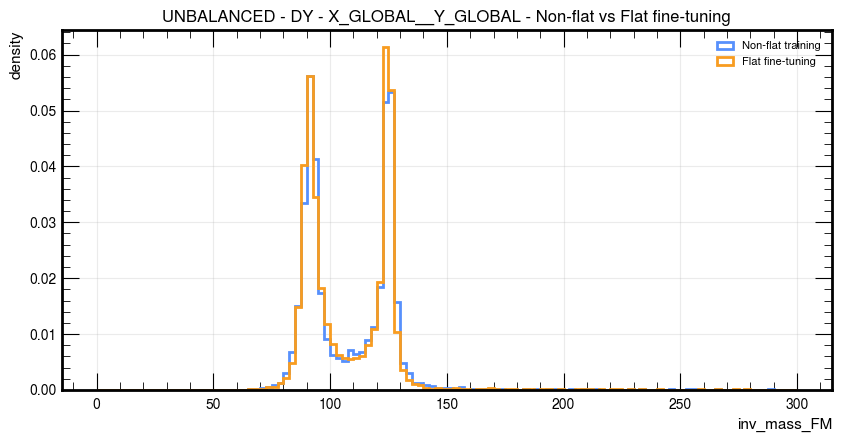

In [84]:
massesPlots.plot_mass_overlay(
    {
        "Non-flat training": masses_unbal_nonflat_h[mode],
        "Flat fine-tuning": masses_unbal_flatft_h[mode],
    },
    title=f"UNBALANCED - HIGGS - {mode} - Non-flat vs Flat fine-tuning",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    {
        "Non-flat training": masses_unbal_nonflat_dy[mode],
        "Flat fine-tuning": masses_unbal_flatft_dy[mode],
    },
    title=f"UNBALANCED - DY - {mode} - Non-flat vs Flat fine-tuning",
    bins=120,
    range_=common_range,
    density=True,
)

In [86]:
mode = "X_GLOBAL__Y_GLOBAL"
window = (110, 140)

rows = []

# BALANCED — non-flat
res = analysis.compute_SB_from_split_masses(
    masses_h=masses_bal_nonflat_h[mode],
    masses_dy=masses_bal_nonflat_dy[mode],
    window=window,
)
rows.append({
    "dataset": "balanced",
    "model": "Non-flat training",
    "mode": mode,
    "N_S": res["N_S"],
    "N_B": res["N_B"],
    "S_over_B": res["S_over_B"],
    "S_over_sqrtB": res["S_over_sqrtB"],
})

# BALANCED — flat FT
res = analysis.compute_SB_from_split_masses(
    masses_h=masses_bal_flatft_h[mode],
    masses_dy=masses_bal_flatft_dy[mode],
    window=window,
)
rows.append({
    "dataset": "balanced",
    "model": "Flat fine-tuning",
    "mode": mode,
    "N_S": res["N_S"],
    "N_B": res["N_B"],
    "S_over_B": res["S_over_B"],
    "S_over_sqrtB": res["S_over_sqrtB"],
})

# UNBALANCED — non-flat
res = analysis.compute_SB_from_split_masses(
    masses_h=masses_unbal_nonflat_h[mode],
    masses_dy=masses_unbal_nonflat_dy[mode],
    window=window,
)
rows.append({
    "dataset": "unbalanced",
    "model": "Non-flat training",
    "mode": mode,
    "N_S": res["N_S"],
    "N_B": res["N_B"],
    "S_over_B": res["S_over_B"],
    "S_over_sqrtB": res["S_over_sqrtB"],
})

# UNBALANCED — flat FT
res = analysis.compute_SB_from_split_masses(
    masses_h=masses_unbal_flatft_h[mode],
    masses_dy=masses_unbal_flatft_dy[mode],
    window=window,
)
rows.append({
    "dataset": "unbalanced",
    "model": "Flat fine-tuning",
    "mode": mode,
    "N_S": res["N_S"],
    "N_B": res["N_B"],
    "S_over_B": res["S_over_B"],
    "S_over_sqrtB": res["S_over_sqrtB"],
})

df_SB_compare = pd.DataFrame(rows)
df_SB_compare

,dataset,model,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,balanced,Non-flat training,X_GLOBAL__Y_GLOBAL,3977,1873,2.123332,91.893904
1,balanced,Flat fine-tuning,X_GLOBAL__Y_GLOBAL,4182,1807,2.314333,98.379577
2,unbalanced,Non-flat training,X_GLOBAL__Y_GLOBAL,20739,3754,5.524507,338.485974
3,unbalanced,Flat fine-tuning,X_GLOBAL__Y_GLOBAL,21104,3715,5.680754,346.246482
